Assignment 4: Training a DCGAN on Fashion-MNIST

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

print("Number of training images:", len(train_dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.8MB/s]

Number of training images: 60000


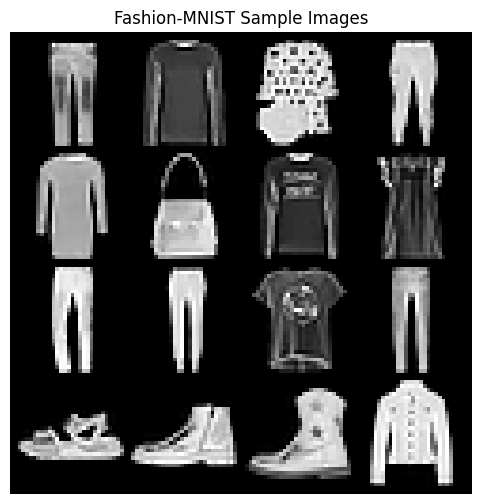

In [4]:
images, labels = next(iter(train_loader))

images_display = images * 0.5 + 0.5

grid = make_grid(images_display[:16], nrow=4)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Fashion-MNIST Sample Images")
plt.show()

In [5]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(noise_dim, 128 * 7 * 7),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64, 1,
                kernel_size=4,
                stride=2,
                padding=1
            ),

            nn.Tanh()
        )

    def forward(self, x):

        x = self.model[0](x)
        x = self.model[1](x)

        x = x.view(x.size(0), 128, 7, 7)

        x = self.model[2:](x)

        return x

In [6]:
noise_dim = 100

generator = Generator(noise_dim).to(device)

test_noise = torch.randn(16, noise_dim).to(device)

generated_images = generator(test_noise)

print("Generated image shape:", generated_images.shape)

Generated image shape: torch.Size([16, 1, 28, 28])


In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            nn.Conv2d(
                1, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),

            nn.Linear(128 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.model(x)

In [8]:
discriminator = Discriminator().to(device)

output = discriminator(generated_images)

print("Discriminator output shape:", output.shape)

Discriminator output shape: torch.Size([16, 1])


In [9]:
nn.BCEWithLogitsLoss()

BCEWithLogitsLoss()

In [10]:
criterion = nn.BCEWithLogitsLoss()

learning_rate = 0.0002

beta1 = 0.5
beta2 = 0.999

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(beta1, beta2)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(beta1, beta2)
)

print("Loss function and optimizers are ready!")

Loss function and optimizers are ready!


In [11]:
num_epochs = 30
noise_dim = 100

generator_losses = []
discriminator_losses = []

fixed_noise = torch.randn(16, noise_dim).to(device)

os.makedirs("generated_images", exist_ok=True)

print("Training settings are ready!")

Training settings are ready!


Epoch [1/30] D Loss: 0.1671 G Loss: 3.5402


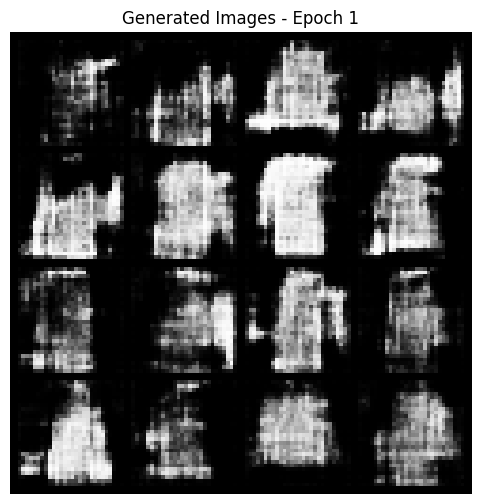

Epoch [2/30] D Loss: 0.2490 G Loss: 3.1630
Epoch [3/30] D Loss: 0.4066 G Loss: 3.3874
Epoch [4/30] D Loss: 0.6922 G Loss: 4.4266
Epoch [5/30] D Loss: 0.4466 G Loss: 2.9183


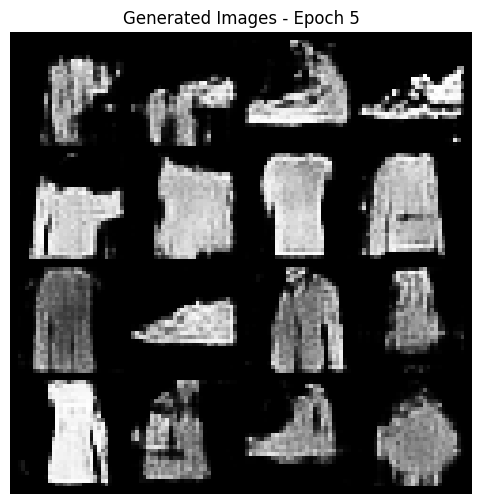

Epoch [6/30] D Loss: 0.5918 G Loss: 1.8150
Epoch [7/30] D Loss: 0.3870 G Loss: 2.9211
Epoch [8/30] D Loss: 0.3711 G Loss: 2.5278
Epoch [9/30] D Loss: 0.4237 G Loss: 1.7094
Epoch [10/30] D Loss: 0.4547 G Loss: 2.0454


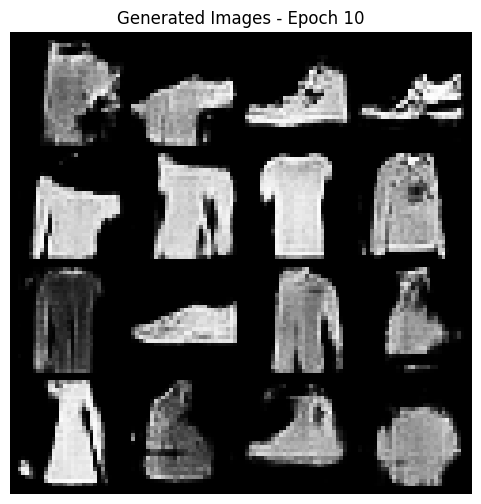

Epoch [11/30] D Loss: 0.7227 G Loss: 2.9846
Epoch [12/30] D Loss: 0.4930 G Loss: 2.3527
Epoch [13/30] D Loss: 0.4450 G Loss: 2.8592
Epoch [14/30] D Loss: 0.4518 G Loss: 2.5619
Epoch [15/30] D Loss: 0.7741 G Loss: 1.6541


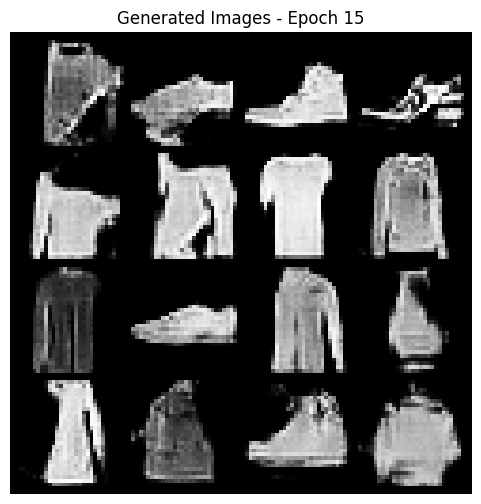

Epoch [16/30] D Loss: 0.4223 G Loss: 1.9623
Epoch [17/30] D Loss: 0.8729 G Loss: 2.8233
Epoch [18/30] D Loss: 0.5313 G Loss: 1.4894
Epoch [19/30] D Loss: 0.4868 G Loss: 1.8071
Epoch [20/30] D Loss: 0.6426 G Loss: 1.2363


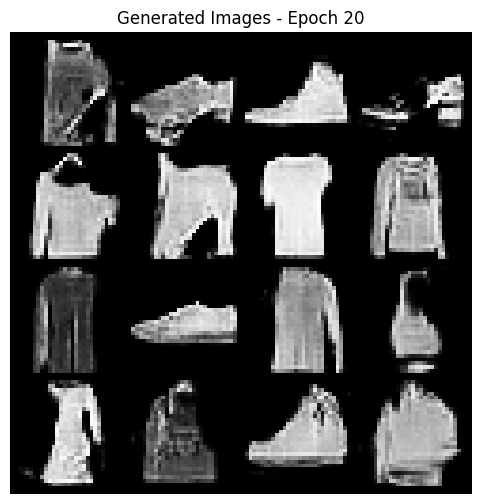

Epoch [21/30] D Loss: 0.4758 G Loss: 2.7155
Epoch [22/30] D Loss: 0.5898 G Loss: 3.1282
Epoch [23/30] D Loss: 0.3694 G Loss: 1.7751
Epoch [24/30] D Loss: 1.3184 G Loss: 0.6810
Epoch [25/30] D Loss: 0.4958 G Loss: 1.5903


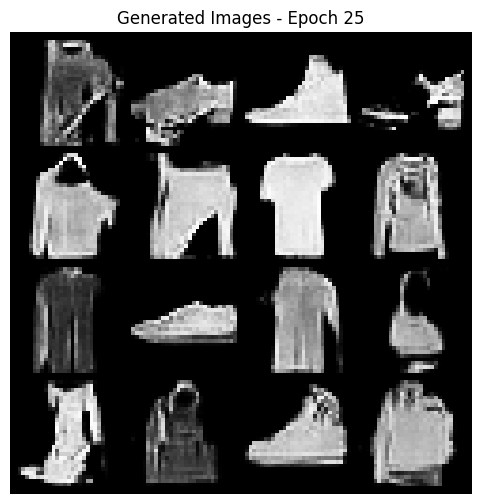

Epoch [26/30] D Loss: 0.4215 G Loss: 2.4959
Epoch [27/30] D Loss: 0.7507 G Loss: 3.1696
Epoch [28/30] D Loss: 0.5216 G Loss: 3.0591
Epoch [29/30] D Loss: 0.4224 G Loss: 2.4979
Epoch [30/30] D Loss: 0.4224 G Loss: 2.4961


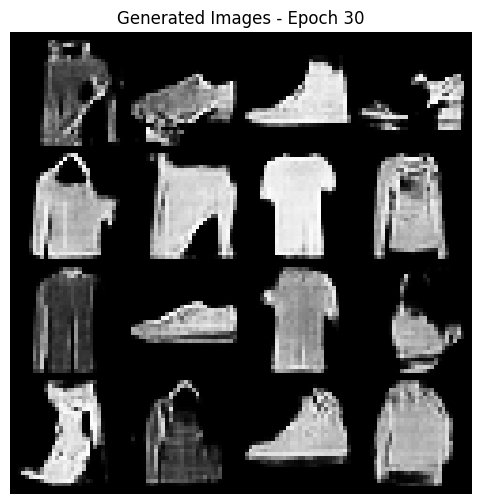

In [12]:
for epoch in range(num_epochs):

    for i, (real_images, _) in enumerate(train_loader):

        real_images = real_images.to(device)

        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)


        optimizer_D.zero_grad()

        real_output = discriminator(real_images)
        d_loss_real = criterion(real_output, real_labels)

        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(noise)

        fake_output = discriminator(fake_images.detach())
        d_loss_fake = criterion(fake_output, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        d_loss.backward()
        optimizer_D.step()



        optimizer_G.zero_grad()

        noise = torch.randn(batch_size, noise_dim).to(device)
        fake_images = generator(noise)

        output = discriminator(fake_images)

        g_loss = criterion(output, real_labels)

        g_loss.backward()
        optimizer_G.step()


        generator_losses.append(g_loss.item())
        discriminator_losses.append(d_loss.item())



    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )


    if (epoch + 1) % 5 == 0 or epoch == 0:

        with torch.no_grad():

            fake_images = generator(fixed_noise).detach().cpu()

            fake_images = (fake_images + 1) / 2

            grid = make_grid(
                fake_images,
                nrow=4,
                padding=2
            )

            plt.figure(figsize=(6, 6))
            plt.imshow(
                grid.permute(1, 2, 0).squeeze(),
                cmap="gray"
            )

            plt.axis("off")
            plt.title(f"Generated Images - Epoch {epoch+1}")

            plt.savefig(
                f"generated_images/epoch_{epoch+1}.png"
            )

            plt.show()

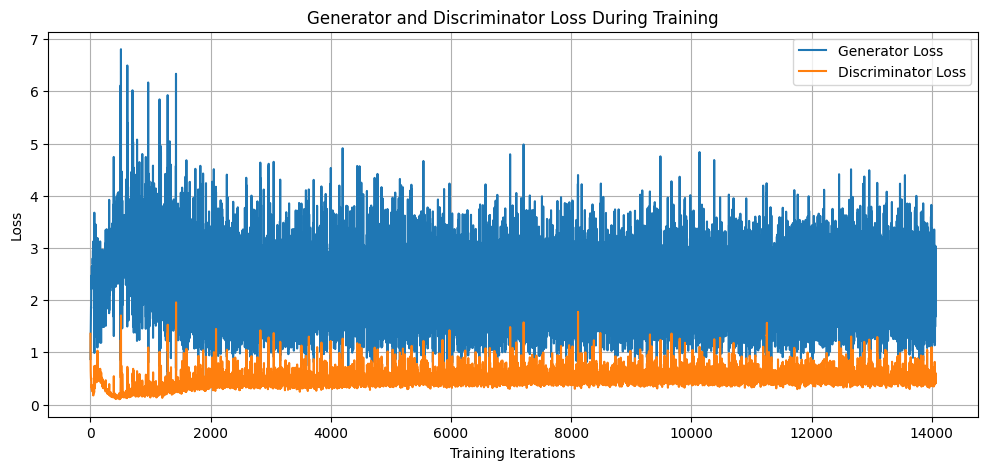

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(generator_losses, label="Generator Loss")

plt.plot(discriminator_losses, label="Discriminator Loss")

plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Loss During Training")

plt.legend()
plt.grid(True)

plt.show()

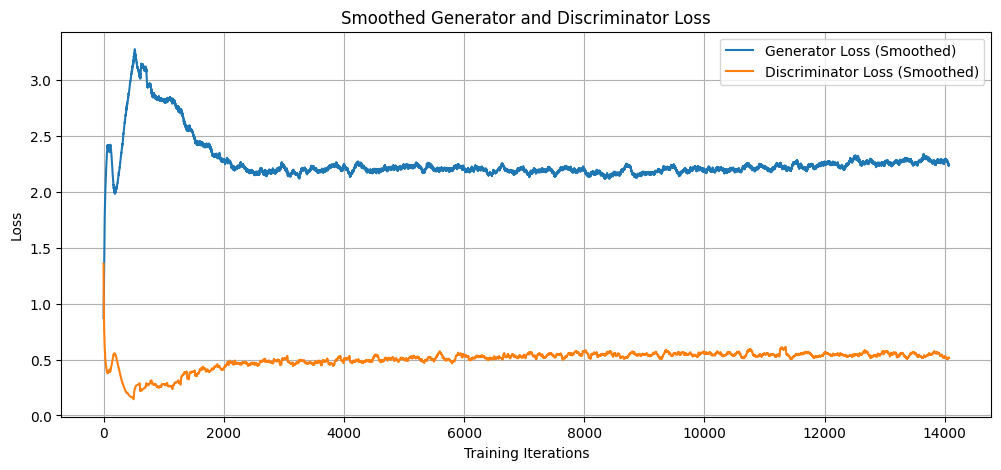

In [14]:
def smooth_losses(losses, window_size=100):
    smoothed = []

    for i in range(len(losses)):
        start = max(0, i - window_size + 1)
        smoothed.append(np.mean(losses[start:i+1]))

    return smoothed


smoothed_g = smooth_losses(generator_losses)
smoothed_d = smooth_losses(discriminator_losses)


plt.figure(figsize=(12, 5))

plt.plot(smoothed_g, label="Generator Loss (Smoothed)")
plt.plot(smoothed_d, label="Discriminator Loss (Smoothed)")

plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.title("Smoothed Generator and Discriminator Loss")

plt.legend()
plt.grid(True)

plt.show()

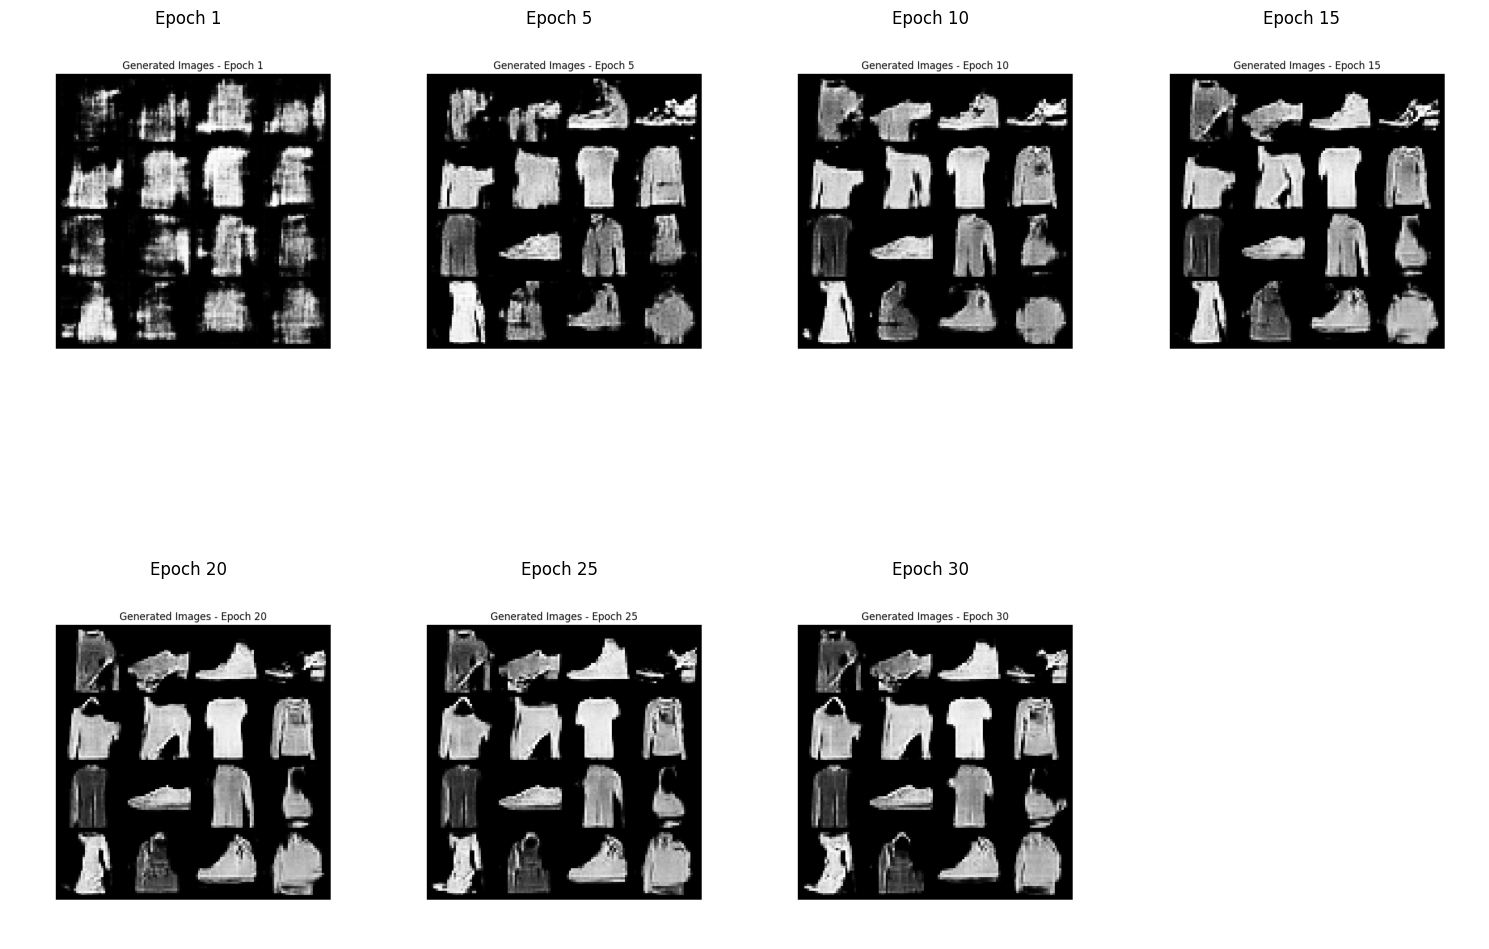

In [15]:
import matplotlib.image as mpimg

epochs_to_show = [1, 5, 10, 15, 20, 25, 30]

plt.figure(figsize=(15, 12))

for i, epoch in enumerate(epochs_to_show):

    image_path = f"generated_images/epoch_{epoch}.png"

    img = mpimg.imread(image_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Epoch {epoch}")

plt.tight_layout()
plt.show()

In this project, a DCGAN was implemented using PyTorch and trained on the Fashion-MNIST dataset. The Generator uses transposed convolution layers to generate new images from random noise, while the Discriminator uses convolution layers to distinguish between real Fashion-MNIST images and fake images generated by the Generator.

The model was trained for 30 epochs. During training, Generator loss and Discriminator loss were recorded. A 4 × 4 grid of generated images was saved at different epochs to observe how the quality of generated images changed over time.